In [10]:

# ==========================================================
# 🌍 END-TO-END AQI PREDICTION PROJECT (SENSOR-BASED)
# ==========================================================

# ======================
# 1. IMPORT LIBRARIES
# ======================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import logging
logging.basicConfig(
    filename='aqi_project.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)



In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

import joblib
import gradio as gr

logging.info("Project Started")

In [12]:
# ======================
# 2. LOAD DATASET
# ======================
df = pd.read_csv("city_day.csv")
logging.info("Dataset Loaded")


In [13]:
print(df.columns.tolist())

['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']


In [14]:
import pandas as pd

# ======================
# LOAD DATASET
# ======================
df = pd.read_csv("city_day.csv")

# ======================
# RENAME COLUMNS (optional – not needed here but keeping structure same)
# ======================
df.rename(columns={
    'PM2.5': 'PM2.5',
    'PM10': 'PM10'
}, inplace=True)

# ======================
# CHECK COLUMNS
# ======================
print(df.columns)

# ======================
# FEATURE SELECTION (MATCH DATASET)
# ======================
features = ['PM2.5','PM10','NO2','CO','SO2','O3']

# ======================
# DROP MISSING VALUES
# ======================
df = df.dropna()

# ======================
# DEFINE X AND y
# ======================
X = df[features]
y = df['AQI']

print("✅ No error now!")

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')
✅ No error now!


In [15]:
# ======================
# 4. BASIC INFO
# ======================
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 6236 entries, 2123 to 29529
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        6236 non-null   object 
 1   Date        6236 non-null   object 
 2   PM2.5       6236 non-null   float64
 3   PM10        6236 non-null   float64
 4   NO          6236 non-null   float64
 5   NO2         6236 non-null   float64
 6   NOx         6236 non-null   float64
 7   NH3         6236 non-null   float64
 8   CO          6236 non-null   float64
 9   SO2         6236 non-null   float64
 10  O3          6236 non-null   float64
 11  Benzene     6236 non-null   float64
 12  Toluene     6236 non-null   float64
 13  Xylene      6236 non-null   float64
 14  AQI         6236 non-null   float64
 15  AQI_Bucket  6236 non-null   object 
dtypes: float64(13), object(3)
memory usage: 828.2+ KB
None
             PM2.5         PM10           NO          NO2          NOx  \
count  6236.000000  62

In [16]:
# Separate numeric and categorical columns
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(exclude=['number']).columns

# Fill numeric columns with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [17]:
# ======================
# 6. OUTLIER DETECTION & TREATMENT
# ======================
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    median = df[col].median()
    
    outliers = (df[col] < lower) | (df[col] > upper)
    count = outliers.sum()
    
    df.loc[outliers, col] = median
    
    print(f"{col}: {count} outliers replaced")

PM2.5: 446 outliers replaced
PM10: 400 outliers replaced
NO2: 55 outliers replaced
CO: 362 outliers replaced
SO2: 263 outliers replaced
O3: 198 outliers replaced


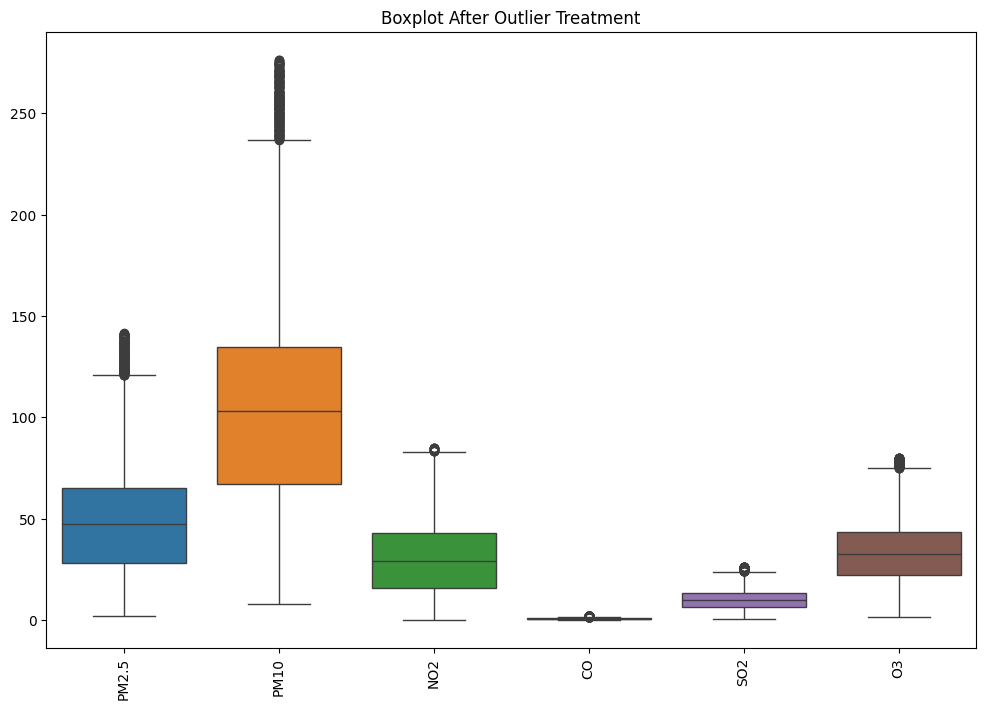

In [18]:
# ======================
# 7. VISUALIZATION
# ======================
plt.figure(figsize=(12,8))
sns.boxplot(data=df[features])
plt.xticks(rotation=90)
plt.title("Boxplot After Outlier Treatment")
plt.show()

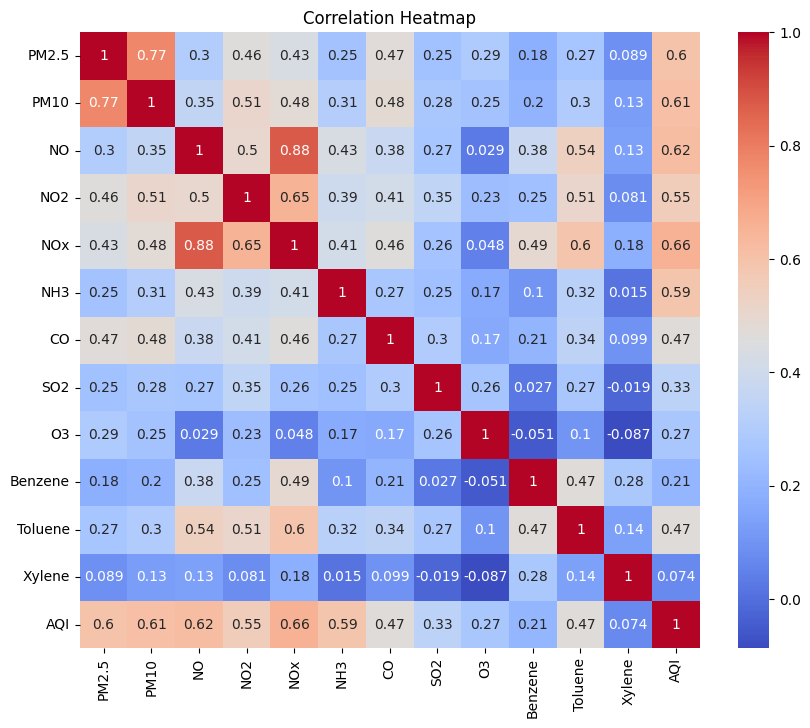

In [20]:
# Drop unnecessary text columns
df = df.drop(columns=['City', 'Date', 'AQI_Bucket'], errors='ignore')

# Fill missing values only for numeric columns
df.fillna(df.median(numeric_only=True), inplace=True)

# Correlation
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# ======================
# 9. VIF CHECK (MULTICOLLINEARITY)
# ======================
X_vif = df[features]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\nVIF Report:\n", vif_data)



VIF Report:
   Feature        VIF
0   PM2.5  10.767607
1    PM10  13.021483
2     NO2   6.101133
3      CO   6.440112
4     SO2   5.786912
5      O3   5.350627


In [21]:
# ======================
# 10. TRAIN TEST SPLIT
# ======================
X = df[features]
target = 'AQI'
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [22]:
# ======================
# 11. SCALING
# ======================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [23]:
# ======================
# 12. MODEL TRAINING
# ======================
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10),
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1),
    "AdaBoost": AdaBoostRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100)
}
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results[name] = (r2, rmse)
    
    print(f"{name} → R²: {r2:.3f}, RMSE: {rmse:.2f}")


Linear Regression → R²: 0.475, RMSE: 68.76
Decision Tree → R²: 0.883, RMSE: 32.44
Random Forest → R²: 0.900, RMSE: 30.08
XGBoost → R²: 0.906, RMSE: 29.02
AdaBoost → R²: 0.736, RMSE: 48.80
Gradient Boosting → R²: 0.904, RMSE: 29.35


In [24]:
# ======================
# 13. SELECT BEST MODEL
# ======================
best_model = RandomForestRegressor(n_estimators=100, max_depth=10)
best_model.fit(X_train_scaled, y_train)

joblib.dump(best_model, "aqi_sensor_model.pkl")

print("\nBest Model Saved: Random Forest")


Best Model Saved: Random Forest


In [25]:
# ======================
# 14. AQI CATEGORY FUNCTION
# ======================
def get_aqi_category(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Satisfactory"
    elif aqi <= 200: return "Moderate"
    elif aqi <= 300: return "Poor"
    elif aqi <= 400: return "Very Poor"
    else: return "Severe"


In [26]:
# ======================
# 15. LOAD MODEL
# ======================
model = joblib.load("aqi_sensor_model.pkl")
scaler = joblib.load("scaler.pkl")


In [27]:
# ======================
# 16. PREDICTION FUNCTION
# ======================
def predict_aqi(pm25, pm10, no, no2, nox, nh3, co, so2, o3, benzene, toluene, xylene):
    
    input_data = np.array([[pm25, pm10, no, no2, nox, nh3, co, so2, o3, benzene, toluene, xylene]])
    
    scaled = scaler.transform(input_data)
    prediction = model.predict(scaled)[0]
    
    category = get_aqi_category(prediction)
    
    return f"{prediction:.2f}", category


In [28]:
# %pip install pyserial

In [29]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Load dataset
df = pd.read_csv("city_day.csv")

# Clean data
df = df.drop(columns=['City','Date','AQI_Bucket'], errors='ignore')
df = df.fillna(df.median(numeric_only=True))

# Features
features = ['PM2.5','PM10','NO2','CO','SO2','O3']
X = df[features]
y = df['AQI']

# Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Save model
joblib.dump(model, "aqi_model_final.pkl")

print("✅ Model saved in current folder")

✅ Model saved in current folder


In [30]:
import os
print(os.getcwd())

c:\Air-Quality-Prediction-Model


In [31]:
import joblib
model = joblib.load("aqi_model_final.pkl")
print("✅ Model loaded successfully")

✅ Model loaded successfully


In [1]:
import serial
import joblib
import pandas as pd
import time

# ==============================
# 1. SERIAL CONNECTION
# ==============================
try:
    ser = serial.Serial('COM5', 9600, timeout=2)
    time.sleep(2)  # wait for Arduino reset
    print("✅ Connected to Arduino on COM5\n")
except:
    print("❌ Error: Check COM port or close Serial Monitor")
    exit()

# ==============================
# 2. LOAD MODEL
# ==============================
model = joblib.load("aqi_model_final.pkl")

# IMPORTANT: only use features your model was trained on
features = ['PM2.5','PM10','NO2','CO','SO2','O3']

# ==============================
# 3. AQI CATEGORY FUNCTION
# ==============================
def get_aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

print("📡 Listening to sensor data...\n")

# ==============================
# 4. READ + PREDICT LOOP
# ==============================
count = 0

try:
    while True:
        line = ser.readline().decode('utf-8', errors='ignore').strip()

        # Skip garbage data
        if not line or ',' not in line:
            continue

        print("Raw:", line)

        try:
            values = list(map(float, line.split(',')))
        except:
            continue  # skip corrupted line

        # Ensure correct length
        if len(values) < 6:
            continue

        # Take first 6 features only
        values = values[:6]

        # Create dataframe with correct feature names
        df = pd.DataFrame([values], columns=features)

        # Predict AQI
        aqi = model.predict(df)[0]
        category = get_aqi_category(aqi)

        print(f"🌍 AQI: {aqi:.2f} | {category}\n")

        time.sleep(2)  # prevent overload

        count += 1
        if count >= 20:
            print("✅ Stopped after 20 readings")
            break

except KeyboardInterrupt:
    print("\n⛔ Stopped manually")

finally:
    ser.close()
    print("🔌 Serial closed")

✅ Connected to Arduino on COM5

📡 Listening to sensor data...

Raw: 429,25.00,60.00
Raw: 427,25.00,60.00
Raw: 427,25.00,60.00
Raw: 427,25.00,60.00
Raw: 425,25.00,60.00
Raw: 427,25.00,60.00
Raw: 427,25.00,60.00
Raw: 427,25.00,60.00
Raw: 427,25.00,60.00
Raw: 427,25.00,60.00
Raw: 427,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 427,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 426,25.00,60.00
Raw: 425,25.00,60.00
Raw: 425,25.00,60.00
Raw: 425,25.00,60.00
Raw: 425,25.00,60.00
Raw: 425,25.00,60.00
Raw: 425,25.00,60.00
Raw: 425,25.0

In [ ]:
# %pip install gradio

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import gradio as gr
print("OK")

OK


In [ ]:
import gradio as gr
import joblib
import pandas as pd

# Load trained model
model = joblib.load("aqi_model_final.pkl")

# Features used in training
features = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']

# AQI category function
def get_aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

# Prediction function
def predict_aqi(pm25, pm10, no2, co, so2, o3):
    input_df = pd.DataFrame([[pm25, pm10, no2, co, so2, o3]], columns=features)
    predicted_aqi = model.predict(input_df)[0]
    category = get_aqi_category(predicted_aqi)
    return f"{predicted_aqi:.2f}", category

# Gradio UI
iface = gr.Interface(
    fn=predict_aqi,
    inputs=[
        gr.Number(label="PM2.5"),
        gr.Number(label="PM10"),
        gr.Number(label="NO2"),
        gr.Number(label="CO"),
        gr.Number(label="SO2"),
        gr.Number(label="O3")
    ],
    outputs=[
        gr.Textbox(label="Predicted AQI"),
        gr.Textbox(label="AQI Category")
    ],
    title="AQI Predictor",
    description="Enter pollutant values to predict AQI"
)

iface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
